In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import root_mean_squared_error, r2_score

In [3]:
df = pd.read_csv("StudentPerformanceFactors.csv")

print("Shape:", df.shape)
df.head()

Shape: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [5]:
df_clean = df.copy()

le = LabelEncoder()

for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = le.fit_transform(df_clean[col])

In [7]:
target = "Exam_Score"  # pastikan sesuai dataset

X = df_clean.drop(columns=[target])
y = df_clean[target]

print("Jumlah fitur:", X.shape[1])

Jumlah fitur: 19


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
models = {
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

In [10]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    results[name] = {"RMSE": rmse, "R2": r2}

# Tampilkan hasil
for model_name, metrics in results.items():
    print(f"\n=== {model_name} ===")
    print(f"RMSE: {metrics['RMSE']:.3f}")
    print(f"R2  : {metrics['R2']:.3f}")


=== DecisionTree ===
RMSE: 3.384
R2  : 0.190

=== RandomForest ===
RMSE: 2.214
R2  : 0.653

=== GradientBoosting ===
RMSE: 1.966
R2  : 0.727


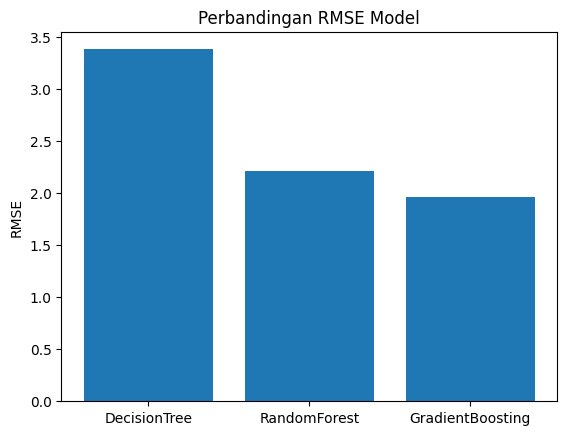

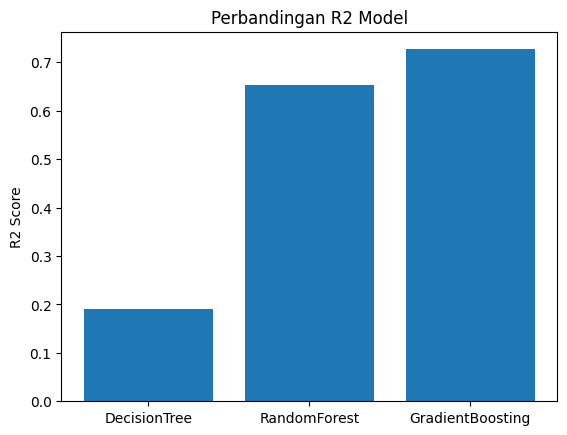

In [11]:
names = list(results.keys())
rmse_vals = [results[m]["RMSE"] for m in names]
r2_vals = [results[m]["R2"] for m in names]

# Plot RMSE
plt.figure()
plt.bar(names, rmse_vals)
plt.title("Perbandingan RMSE Model")
plt.ylabel("RMSE")
plt.show()

# Plot R2
plt.figure()
plt.bar(names, r2_vals)
plt.title("Perbandingan R2 Model")
plt.ylabel("R2 Score")
plt.show()

In [12]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

feat_imp.head(10)

,feature,importance
1,Attendance,0.381449
0,Hours_Studied,0.242662
6,Previous_Scores,0.091385
9,Tutoring_Sessions,0.035440
3,Access_to_Resources,0.028868
5,Sleep_Hours,0.028611
14,Physical_Activity,0.028010
2,Parental_Involvement,0.026583
10,Family_Income,0.019824
13,Peer_Influence,0.018788


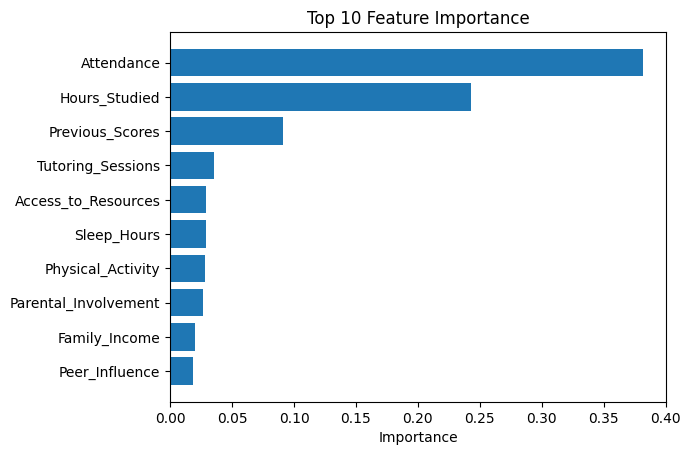

In [13]:
top10 = feat_imp.head(10)

plt.figure()
plt.barh(top10["feature"], top10["importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.show()

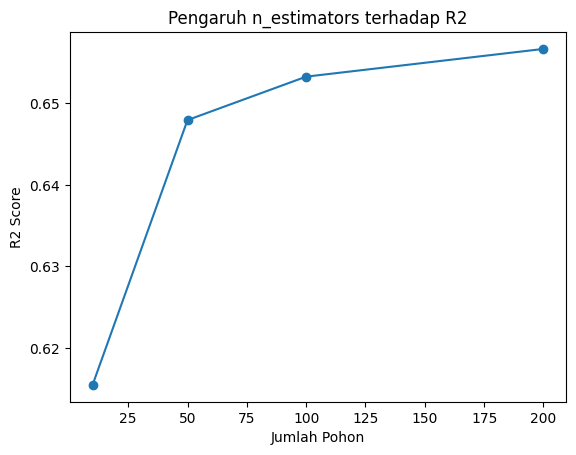

In [14]:
estimators = [10, 50, 100, 200]
r2_scores = []

for n in estimators:
    model = RandomForestRegressor(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    r2_scores.append(r2_score(y_test, pred))

# Plot
plt.figure()
plt.plot(estimators, r2_scores, marker='o')
plt.title("Pengaruh n_estimators terhadap R2")
plt.xlabel("Jumlah Pohon")
plt.ylabel("R2 Score")
plt.show()